## How well do jobs and skills pay for Data Engineers?

#### Methology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Engineer
3. Visualize for highest paying and most demanded skills 

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\david\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_Ger = df[df['job_country'] == 'Germany'].dropna(subset=['salary_year_avg']) 

In [6]:
job_titles = df_Ger['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Analyst',
 'Data Scientist',
 'Data Engineer',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Senior Data Scientist']

In [7]:
job_ger_top5 = df_Ger[df_Ger['job_title_short'].isin(job_titles)]

In [18]:
job_order = job_ger_top5.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index


C:\Users\david\AppData\Local\Temp\ipykernel_5856\1442127548.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=job_ger_top5, x='salary_year_avg', y='job_title_short', order=job_order, palette='crest')


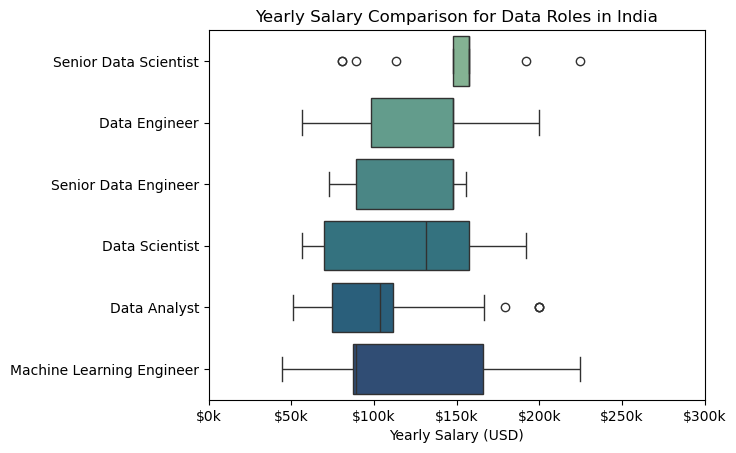

In [23]:
sns.boxplot(data=job_ger_top5, x='salary_year_avg', y='job_title_short', order=job_order, palette='crest')
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()

In [27]:
df_DA_Ger = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].copy()

df_DA_Ger = df_DA_Ger.dropna(subset='salary_year_avg')

In [29]:
df_DA_Ger = df_DA_Ger.explode('job_skills')

df_DA_Ger[['salary_year_avg' , 'job_skills']].head()

,salary_year_avg,job_skills
20066,75067.5,r
20066,75067.5,python
20066,75067.5,java
20066,75067.5,c#
20066,75067.5,sql


In [42]:
df_DA_top_pay = df_DA_Ger.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

df_DA_top_pay

,count,median
job_skills,,
github,3,199675.0
terraform,1,166419.5
bigquery,1,166419.5
redshift,1,166419.5
nosql,1,166419.5
kafka,1,166419.5
gcp,3,165000.0
javascript,1,111175.0
terminal,1,111175.0


In [35]:
df_DA_most_pop = df_DA_Ger.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_most_pop = df_DA_most_pop.head(10).sort_values(by='median', ascending=False)

df_DA_most_pop

,count,median
job_skills,,
python,18,111175.0
spark,7,111175.0
pandas,4,108412.5
excel,7,105650.0
sql,24,101500.0
tableau,13,100500.0
power bi,4,83937.5
r,7,75067.5
looker,5,53014.0


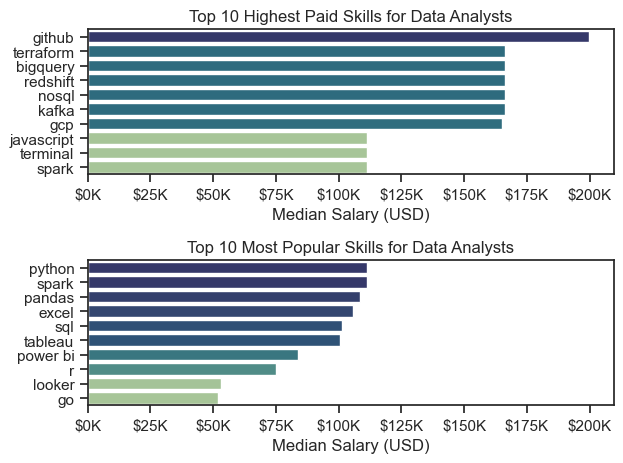

In [45]:
fig, ax = plt.subplots(2,1)
sns.set_theme(style='ticks')

# Top 10 Highest Paid Skills for Data Analysts (Germany)
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, hue='median', ax=ax[0], palette='crest')
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('Median Salary (USD)')
ax[0].set_xlim(ax[0].get_xlim())
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

sns.barplot(data=df_DA_most_pop, x='median', y=df_DA_most_pop.index, hue='median', ax=ax[1], palette='crest')
ax[1].legend().remove()
ax[1].set_title('Top 10 Most Popular Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()
